#**REDES NEURONALES CONVOLUTIVAS**

Una empresa de tecnología está desarrollando un sistema de reconocimiento de gestos de manos para controlar dispositivos mediante visión por computadora. Para ello, necesita entrenar una red  neuronal convolutiva (CNN) que pueda clasificar diferentes posiciones de la mano a partir de  imágenes.
Tu tarea es crear y optimizar una CNN para clasificar imágenes de la base de datos SignMNIST, que  contiene gestos del lenguaje de señas americano (ASL). Este conjunto de datos se encuentra  disponible en la librería TensorFlow Datasets (TFDS).

Para completar la actividad, deberás implementar y entrenar un modelo de CNN, evaluar su  rendimiento y mejorarlo con técnicas de optimización.

**Sobre el dataset:**

Disponible en https://www.kaggle.com/datasets/datamunge/sign-language-mnist/data

Each training and test case represents a label (0-25) as a one-to-one map for each alphabetic letter A-Z (and no cases for 9=J or 25=Z because of gesture motions). The training data (27,455 cases) and test data (7172 cases) are approximately half the size of the standard MNIST but otherwise similar with a header row of label, pixel1,pixel2….pixel784 which represent a single 28x28 pixel image with grayscale values between 0-255.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ruta_archivos = '/content/drive/MyDrive/bootcamp_ciencia_de_datos/evaluaciones/archivos/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

import tensorflow as tf

from tensorflow.keras.models import Sequential  # type: ignore
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Reshape, BatchNormalization, Resizing, Activation # type:ignore
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomTranslation, RandomFlip, RandomContrast # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # type: ignore

import random
import os
random_seed = 42
os.environ['PYTHONHASHSEED'] = str(random_seed)

##**1. Carga y exploración del dataset (1 punto)**
- Cargar el dataset SignMNIST desde TensorFlow Datasets.
- Dividirlo en conjunto de entrenamiento y prueba.
- Normalizar las imágenes para que sus valores estén entre 0 y 1.
- Mostrar algunas imágenes del conjunto de datos con sus etiquetas correspondientes.

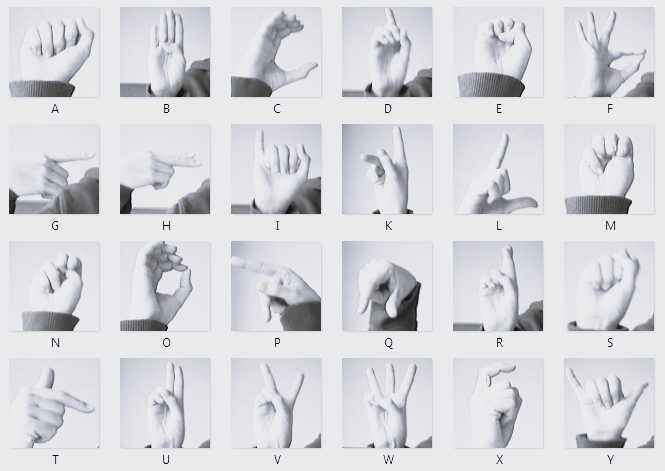

###**Cargar train set**

In [ ]:
df = pd.read_csv(ruta_archivos + 'sign_mnist_train.csv')

print(f'Dimensión del dataset: {df.shape}')
atributos = df.columns[1:]
print(f'Número de atributos: {len(atributos)} (28 * 28 pixeles, en escala de grises de 0 a 255 variaciones de color)')
print(f'Columna target: "label"')
print('\nVistazo al dataset:\n')
df.head()

Dimensión del dataset: (27455, 785)
Número de atributos: 784 (28 * 28 pixeles, en escala de grises de 0 a 255 variaciones de color)
Columna target: "label"

Vistazo al dataset:



,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [ ]:
letras = df.label.unique()
print(f'Número de letras: {len(letras)}')
print(f'Letras: {sorted([int(l) for l in letras])}')

Número de letras: 24
Letras: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


La letra asociada al número 9 (letra "J") no está presente en el dataset. Para tener etiquetas contiguas, hay que mapear el label desde 0 al número de letras presentes en el dataset.

In [ ]:
# renombrar las etiquetas de columna "label"

encoder = LabelEncoder()
df['label'] = encoder.fit_transform(df['label'])

In [ ]:
# convertir números a letras y viceversa

import string

alfabeto = list(string.ascii_uppercase)
alfabeto.remove('J')
alfabeto.remove('Z')
letras_a_num = {letra: num for num, letra in enumerate(alfabeto)}
num_a_letras = {num: letra for num, letra in enumerate(alfabeto)}

In [ ]:
print(f'Cantidad de duplicados: {df.duplicated().sum()}')
print(f'Cantidad de nulos: {df.isna().sum().sum()}')

Cantidad de duplicados: 0
Cantidad de nulos: 0


###**Cargar test set**

In [ ]:
# leer data
df_test = pd.read_csv(ruta_archivos + 'sign_mnist_test.csv')

# corregir las etiquetas de columna "label"
df_test['label'] = encoder.transform(df_test['label'])

print(f'Dimensión del dataset: {df_test.shape}')
print('Vistazo al dataset:')
df_test.head()

Dimensión del dataset: (7172, 785)
Vistazo al dataset:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,9,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [ ]:
print(f'Cantidad de duplicados: {df_test.duplicated().sum()}')
print(f'Cantidad de nulos: {df_test.isna().sum().sum()}')

Cantidad de duplicados: 0
Cantidad de nulos: 0


###**Creación de conjuntos Train y Test**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(df[atributos], df['label'], test_size=0.20, random_state=42, stratify=df['label'])
print(f'Dimensión del conjunto de entrenamiento: {X_train.shape}')
print(f'Dimensión del conjunto de validación: {X_val.shape}')

X_test = df_test[atributos]
y_test = df_test['label']
print(f'Dimensión del conjunto de testeo: {X_test.shape}')

Dimensión del conjunto de entrenamiento: (21964, 784)
Dimensión del conjunto de validación: (5491, 784)
Dimensión del conjunto de testeo: (7172, 784)


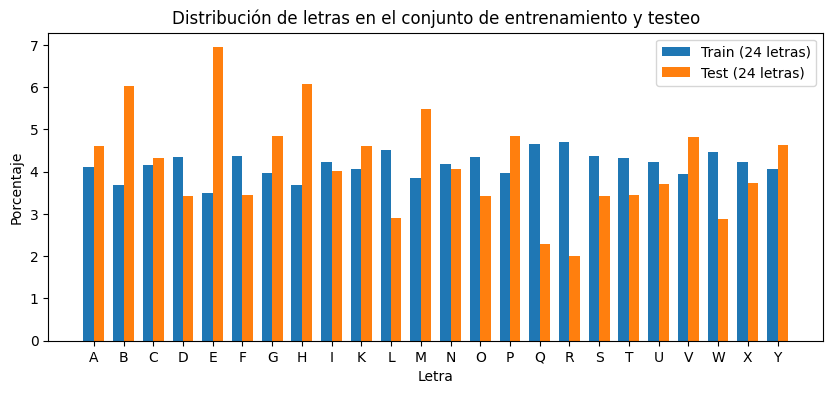

In [ ]:
# distribución de letras en conjuntos de entrenamiento y testeo

train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()

plt.figure(figsize=(10, 4))

bar_width = 0.35
index = np.arange(len(train_dist.index))

plt.bar(index, train_dist.values*100, bar_width, label='Train ('+str(train_dist.index.nunique()) +' letras)')
plt.bar(index + bar_width, test_dist.values*100, bar_width, label='Test ('+str(test_dist.index.nunique()) +' letras)')

plt.xlabel('Letra')
plt.ylabel('Porcentaje')
plt.title('Distribución de letras en el conjunto de entrenamiento y testeo')
plt.xticks(index + bar_width / 2, letras_a_num.keys())

plt.legend()
plt.plot();

###**Normalizar**

In [ ]:
X_train = X_train / 255.0
X_val = X_val / 255.0
X_test = X_test / 255.0

###**Visualizar algunas imágenes**

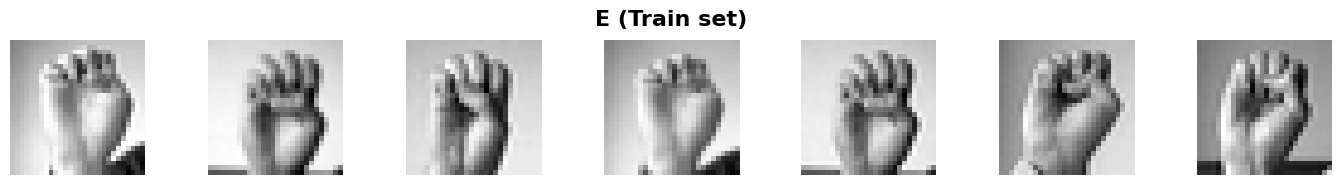

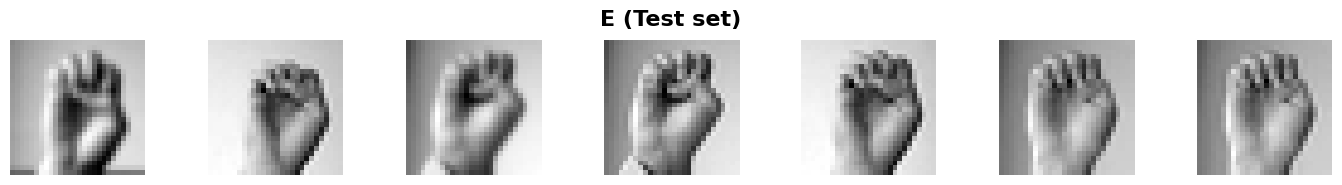

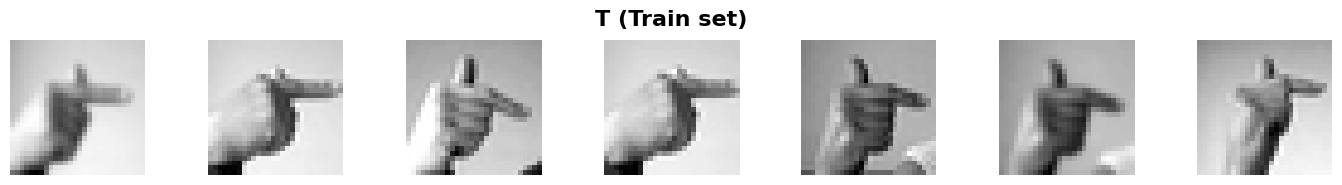

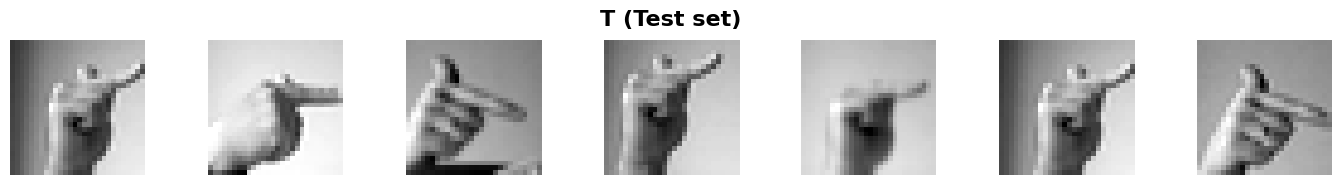

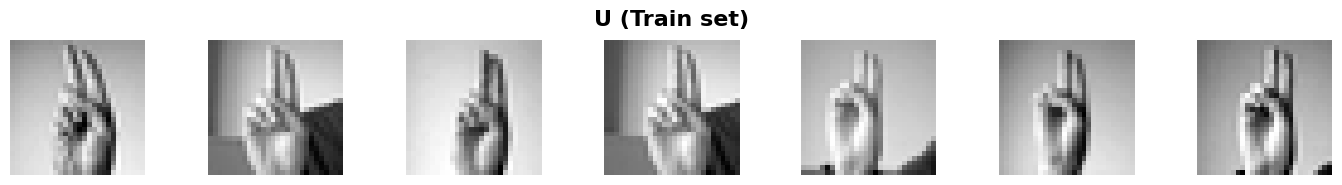

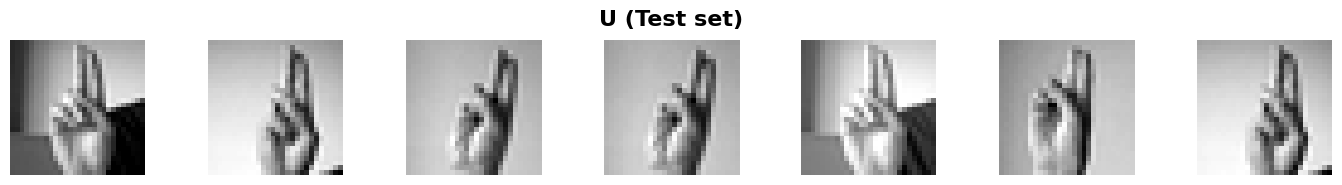

In [ ]:
def dibujar_letra(df, letra, num_imgs=7):
    '''
    Muestra num_imgs imágenes elegidas al azar para una misma letra que se encuentra en el dataset df.
    Params:
      - df: dataframe, que contiene la etiqueta "label"
      - letra: str
      - num_imgs: int, número de imágenes a mostrar
    '''
    if num_imgs > 7:
        print('Máximo 7 imágenes por letra')
        return

    letra_ = letras_a_num[letra]
    df_letra = df.drop(columns=['label'])[df['label'] == letra_].reset_index(drop=True)
    indices = np.random.choice(df_letra.index, size=num_imgs, replace=False)

    fig, axs = plt.subplots(1, num_imgs, figsize=(2*num_imgs, 2))
    axs = axs.flatten()
    for i, idx in enumerate(indices):
        img = df_letra.iloc[idx, :].values.reshape(28, 28)
        axs[i].imshow(img, cmap='gray')
        axs[i].axis("off")
    msg = 'Test set' if df is df_test else 'Train set'
    fig.suptitle(f'{letra} ({msg})', fontsize=16, weight='bold', y=0.9)
    plt.tight_layout()
    plt.show()

dibujar_letra(df, 'E')
dibujar_letra(df_test, 'E')
dibujar_letra(df, 'T')
dibujar_letra(df_test, 'T')
dibujar_letra(df, 'U')
dibujar_letra(df_test, 'U')

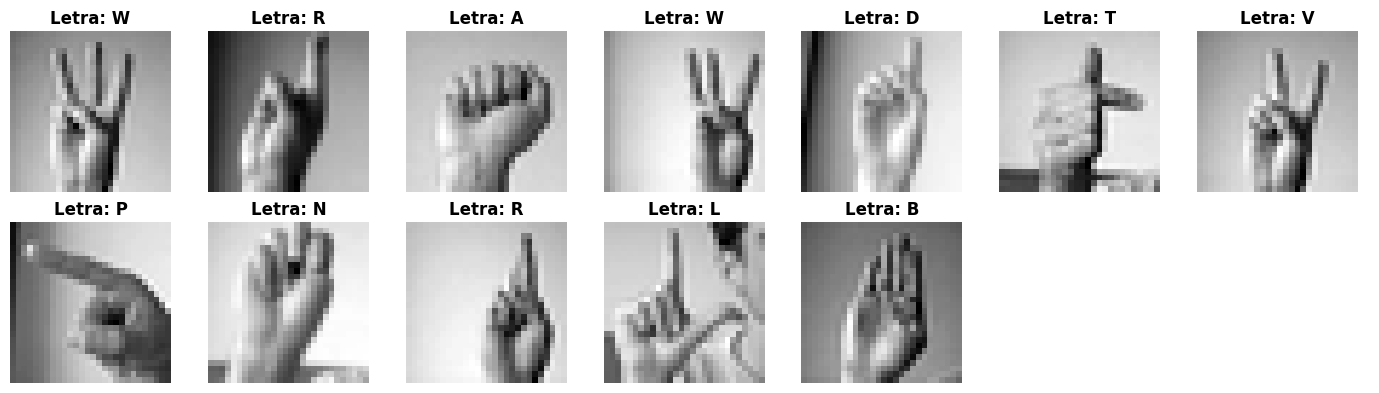

In [ ]:
def dibujar_letras_y_predicciones(X, y, y_pred=None):
    '''
    Dibuja las imágenes correspondientes a los datos asociados a X.
    Params:
      - X: dataframe or numpy array
      - y: array or list, true labels
      - y_pred: array or list, predicciones del modelo
    '''

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    if isinstance(y, pd.Series):
        y = y.to_numpy()
    if y_pred is not None and isinstance(y_pred, pd.Series):
        y_pred = y_pred.to_numpy()


    num_cols = 7
    num_rows = np.ceil(len(X) / num_cols).astype(int)
    fig, axs = plt.subplots(num_rows, num_cols, figsize=(2*num_cols, 2*num_rows))
    axs = axs.flatten()
    for i in range(len(X)):
        axs[i].imshow(X[i, :].reshape(28, 28), cmap='gray')
        axs[i].axis("off")

        if y_pred is not None:
            axs[i].set_title(f'{num_a_letras[y[i]]} (Pred: {num_a_letras[y_pred[i]]})', weight='bold')
        else:
            axs[i].set_title(f'Letra: {num_a_letras[y[i]]}', weight='bold')

    for j in range(len(X), len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()


dibujar_letras_y_predicciones(X_train.head(12), y_train.head(12))

##**2. Definición del modelo de Red Neuronal Convolutiva (2 puntos)**
- Definir una CNN con al menos tres capas convolucionales.
- Incluir capas de Pooling para reducir la dimensionalidad.
- Aplicar una capa de Flattening antes de la capa densa.
- Agregar al menos una capa densa totalmente conectada y una capa de salida con activación  softmax para clasificación multiclase.

In [ ]:
# definir red neuronal convolutiva

# adaptar los labels
y_train_c = to_categorical(y_train, num_classes=len(letras))
y_val_c = to_categorical(y_val, num_classes=len(letras))

input_shape  = (28 * 28,) # formato vector entrada
target_shape = (28, 28, 1) # formato imagen (1 canal) (en vez de un previo reshape los datasets)

modelo = Sequential()
modelo.add(Input(shape=input_shape))
modelo.add(Reshape(target_shape))

modelo.add(Conv2D(32, (3, 3), activation='relu'))
modelo.add(MaxPooling2D((2, 2)))

modelo.add(Conv2D(64, (3, 3), activation='relu'))
modelo.add(MaxPooling2D((2, 2)))

modelo.add(Conv2D(128, (3, 3), activation='relu'))
modelo.add(MaxPooling2D((2, 2)))
modelo.add(Flatten())

modelo.add(Dense(128, activation='relu'))

modelo.add(Dense(len(letras), activation='softmax'))

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,280 (438.59 KB)

 Trainable params: 112,280 (438.59 KB)

 Non-trainable params: 0 (0.00 B)

##**3. Compilación y entrenamiento del modelo (2 puntos)**
- Compilar el modelo usando la función de pérdida adecuada para clasificación multiclase.
- Entrenar el modelo con un optimizador adecuado.
- Usar early stopping para evitar sobreajuste si es necesario.

In [ ]:
%%time

# setear semillas para reproducibilidad
random.seed(random_seed)
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# métrica de evaluación = accuracy
earlyStop = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy')

# compilar
modelo.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# entrenar
history = modelo.fit(X_train, y_train_c, batch_size=128, epochs=100, validation_data=(X_val, y_val_c), callbacks=[earlyStop])

best_iter = np.argmax(history.history['val_accuracy']) + 1
print(f'\n\nMejor iteración: {best_iter}')

loss, accuracy = modelo.evaluate(X_val, y_val_c, verbose=0)
print(f'\n\nLoss en el conjunto de validación: {loss:.4f}')
print(f'Accuracy en el conjunto de validación: {accuracy:.2%}')

Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.1705 - loss: 2.7593 - val_accuracy: 0.6159 - val_loss: 1.2080
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 114ms/step - accuracy: 0.6738 - loss: 0.9938 - val_accuracy: 0.8095 - val_loss: 0.6034
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.8402 - loss: 0.5058 - val_accuracy: 0.9140 - val_loss: 0.2975
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.9273 - loss: 0.2551 - val_accuracy: 0.9674 - val_loss: 0.1446
Epoch 5/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 116ms/step - accuracy: 0.9703 - loss: 0.1255 - val_accuracy: 0.9880 - val_loss: 0.0771
Epoch 6/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.9883 - loss: 0.0657 - val_accuracy: 0.9924 - val_loss: 0.0468
Epoch 7/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.9956 - loss: 0.0353 - val_accuracy: 0.9975 - val_loss: 0.0251
Epoch 8/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - accuracy: 0.9976 -

##**4. Evaluación del modelo (2 puntos)**
- Evaluar la precisión del modelo en el conjunto de prueba.
- Graficar las curvas de precisión y pérdida en las épocas de entrenamiento.
- Generar una matriz de confusión para analizar los errores del modelo.

In [ ]:
# evaluar accuracy del modelo en el test set
y_test_proba = modelo.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_proba, axis=1)

acc_test_original = accuracy_score(y_test, y_test_pred)
print(f'Accuracy en el test_set para el modelo inicial: {acc_test_original:.2%}')

Accuracy en el test_set para el modelo inicial: 89.29%


In [ ]:
# un vistazo a las primeras 5 prediciones según el modelo inicial para el test set

df_preds = pd.DataFrame({'label': df_test.label, 'pred': y_test_pred})
df_preds.head()

,label,pred
0,6,6
1,5,5
2,9,9
3,0,0
4,3,3


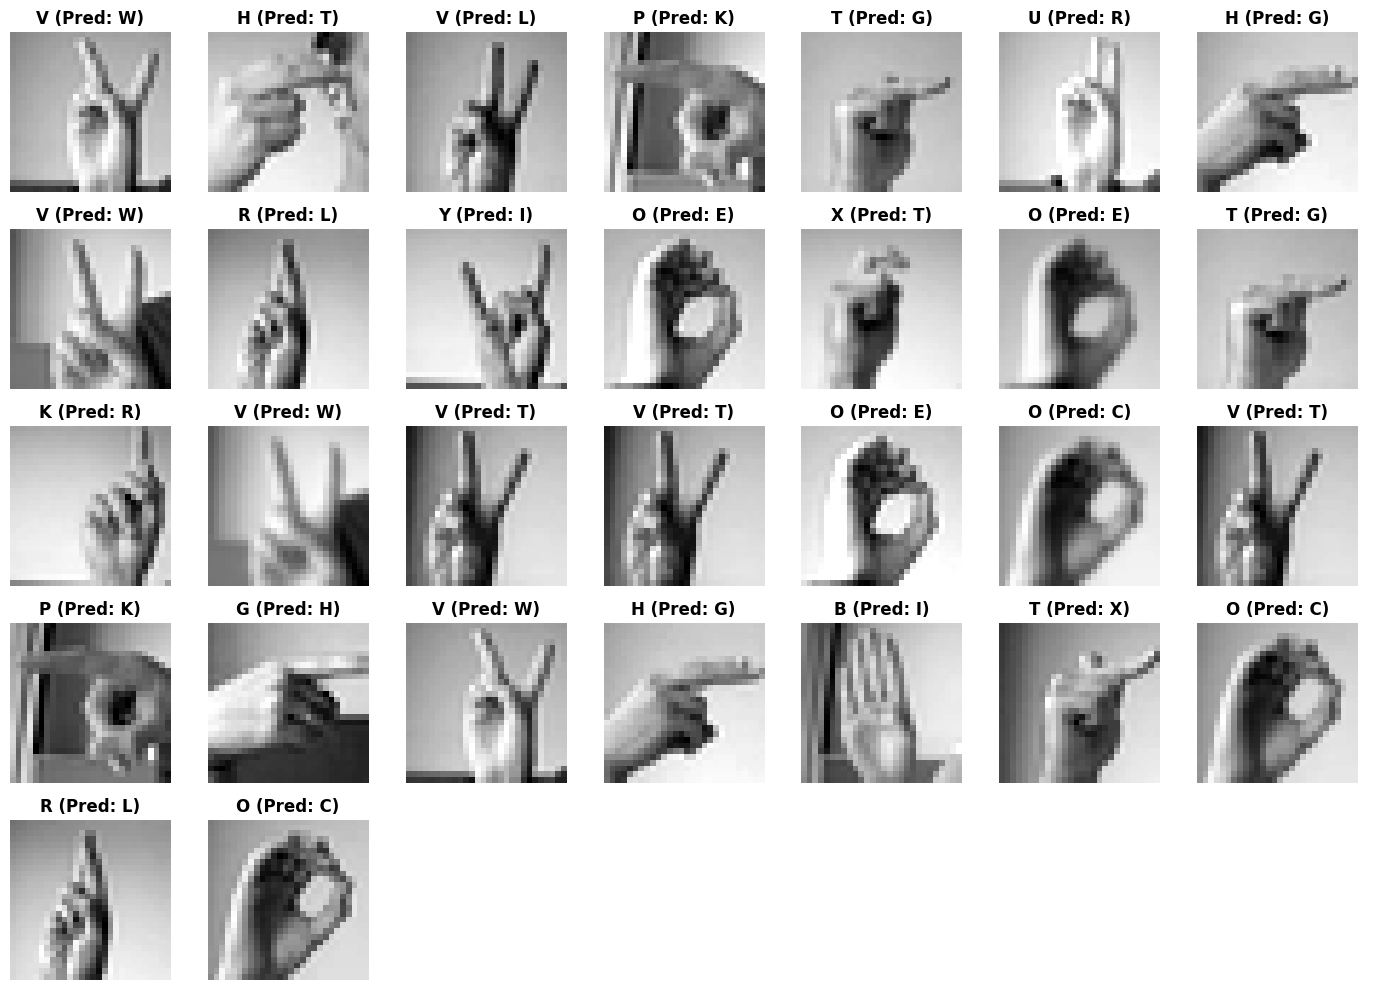

In [ ]:
# buscar predicciones fallidas y visualizar

k = 30 # ver 30 fallos
criterio_fallos_inicial = df_preds['label'] != df_preds['pred']
df_fallos_inicial = X_test[criterio_fallos_inicial][:k]
y_fallos_inicial = y_test[criterio_fallos_inicial][:k]
y_pred_fallos_inicial = y_test_pred[criterio_fallos_inicial][:k]

dibujar_letras_y_predicciones(df_fallos_inicial, y_fallos_inicial, y_pred_fallos_inicial)

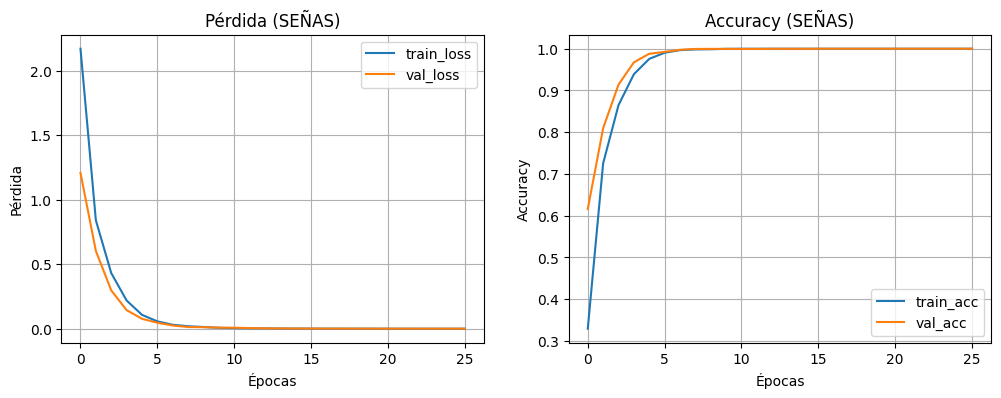

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Épocas"); plt.ylabel("Pérdida"); plt.title("Pérdida (SEÑAS)")
plt.grid(True); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Épocas"); plt.ylabel("Accuracy"); plt.title("Accuracy (SEÑAS)")
plt.grid(True); plt.legend()
plt.show()

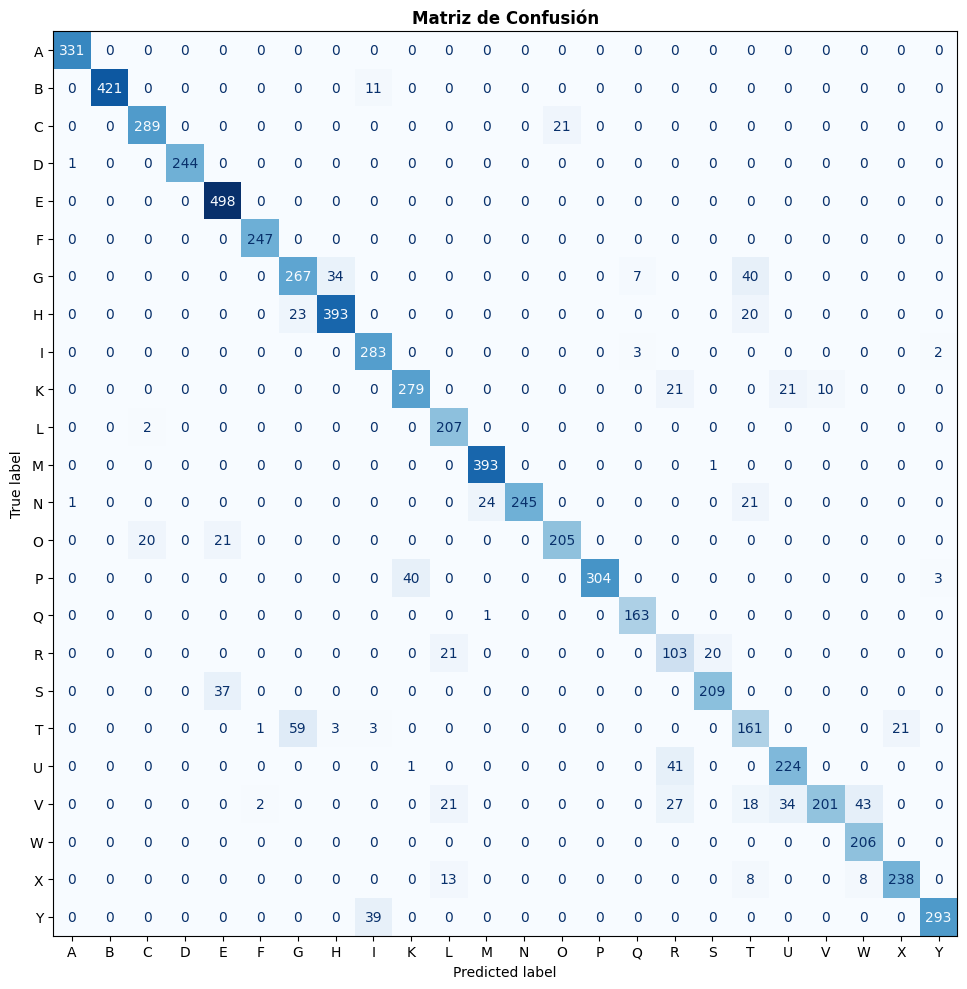

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=[num_a_letras[i] for i in sorted(y_test.unique())], cmap='Blues', colorbar=False)
fig = disp.ax_.get_figure()
fig.set_size_inches(10, 10)
plt.title('Matriz de Confusión', weight='bold')
plt.tight_layout()

plt.show()

##**5. Optimización del modelo (3 puntos)**
- Aplicar técnicas de mejora del modelo:
    -  Aumento de datos (Data Augmentation) para mejorar la generalización.
    - Regularización con Dropout para evitar el sobreajuste.
    - Cambio de hiperparámetros, como tasa de aprendizaje o número de filtros.
- Comparar el rendimiento del modelo antes y después de la optimización.
- Explicar qué cambios fueron los más efectivos y por qué.

###**Mejora del modelo**

En la definición del modelo voy a agregar capas de:
- aumento de datos,
- batchnormalization,
- dropout

In [ ]:
# Capa de aumento de datos
seed_aug = 0
data_augmentation = Sequential([
    #RandomFlip("horizontal", seed=seed_aug),        # voltear horizontalmente
    RandomRotation(0.05, seed=seed_aug),             # rotación aleatoria
    RandomZoom(0.05, seed=seed_aug),                 # zoom aleatorio
    RandomTranslation(0.05, 0.05, seed=seed_aug),     # traslación en ambas direcciones
    #RandomContrast(0.05, seed=seed_aug)             # contraste aleatorio
], name="data_augmentation")

# definir el nuevo modelo
modelo_aug = Sequential()
modelo_aug.add(Input(shape=input_shape))
modelo_aug.add(Reshape(target_shape))

modelo_aug.add(data_augmentation)

modelo_aug.add(Conv2D(32, (3, 3), activation='relu'))
modelo_aug.add(BatchNormalization())
modelo_aug.add(MaxPooling2D((2, 2)))

modelo_aug.add(Conv2D(64, (3, 3), activation='relu'))
modelo_aug.add(BatchNormalization())
modelo_aug.add(MaxPooling2D((2, 2)))

modelo_aug.add(Conv2D(128, (3, 3), activation='relu'))
modelo_aug.add(BatchNormalization())
modelo_aug.add(MaxPooling2D((2, 2)))

modelo_aug.add(Flatten())
modelo_aug.add(Dense(128))
modelo_aug.add(BatchNormalization())
modelo_aug.add(Activation('relu'))
modelo_aug.add(Dropout(0.2))

modelo_aug.add(Dense(len(letras), activation='softmax'))

modelo_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_1 (Reshape)             │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,688 (444.09 KB)

 Trainable params: 112,984 (441.34 KB)

 Non-trainable params: 704 (2.75 KB)

- Para el entrenamiento voy a agregar un callback para la tasa de aprendizaje.

In [ ]:
%%time

random.seed(random_seed)
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

earlyStop = EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy')
reduce_lr = ReduceLROnPlateau(monitor="val_accuracy", factor=0.8, patience=3)

modelo_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_aug = modelo_aug.fit(X_train, y_train_c, batch_size=128, epochs=100, validation_data=(X_val, y_val_c), callbacks=[earlyStop, reduce_lr])

best_iter_aug = np.argmax(history_aug.history['val_accuracy']) + 1
print(f'\n\nMejor iteración: {best_iter_aug}')

loss_aug, accuracy_aug = modelo_aug.evaluate(X_val, y_val_c, verbose=0)
print(f'Loss en el conjunto de validación: {loss_aug:.4f}')
print(f'Accuracy en el conjunto de validación: {accuracy_aug:.2%}')

y_test_pred_proba = modelo_aug.predict(X_test)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)

acc_test_aug = accuracy_score(y_test, y_test_pred)
print(f'Accuracy en el test set para el modelo aumentado: {acc_test_aug:.2%}')

Epoch 1/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 34s 175ms/step - accuracy: 0.4840 - loss: 1.8341 - val_accuracy: 0.1076 - val_loss: 3.9687 - learning_rate: 0.0010
Epoch 2/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 30s 172ms/step - accuracy: 0.9294 - loss: 0.3087 - val_accuracy: 0.3300 - val_loss: 2.9012 - learning_rate: 0.0010
Epoch 3/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 171ms/step - accuracy: 0.9724 - loss: 0.1273 - val_accuracy: 0.8845 - val_loss: 0.4659 - learning_rate: 0.0010
Epoch 4/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 31s 179ms/step - accuracy: 0.9879 - loss: 0.0646 - val_accuracy: 0.9829 - val_loss: 0.1009 - learning_rate: 0.0010
Epoch 5/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 179ms/step - accuracy: 0.9896 - loss: 0.0474 - val_accuracy: 0.9885 - val_loss: 0.0529 - learning_rate: 0.0010
Epoch 6/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.9938 - loss: 0.0336 - val_accuracy: 0.9800 - val_loss: 0.0627 - learning_rate: 0.0010
Epoch 7/100
172/172 ━━━━━━━━━━━━━━━━━━━━ 36s 208ms/step - accura

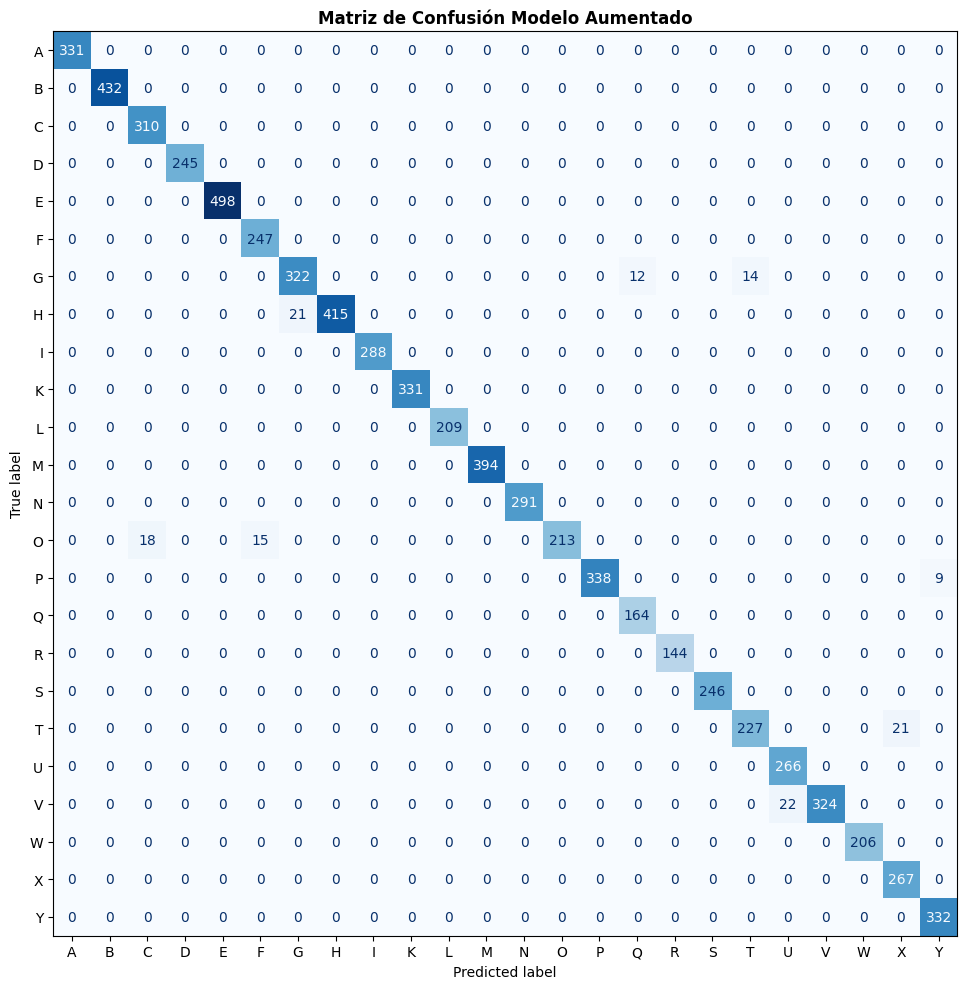

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=[num_a_letras[i] for i in sorted(y_test.unique())], cmap='Blues', colorbar=False)
fig = disp.ax_.get_figure()
fig.set_size_inches(10, 10)
plt.title('Matriz de Confusión Modelo Aumentado', weight='bold')
plt.tight_layout()

plt.show()

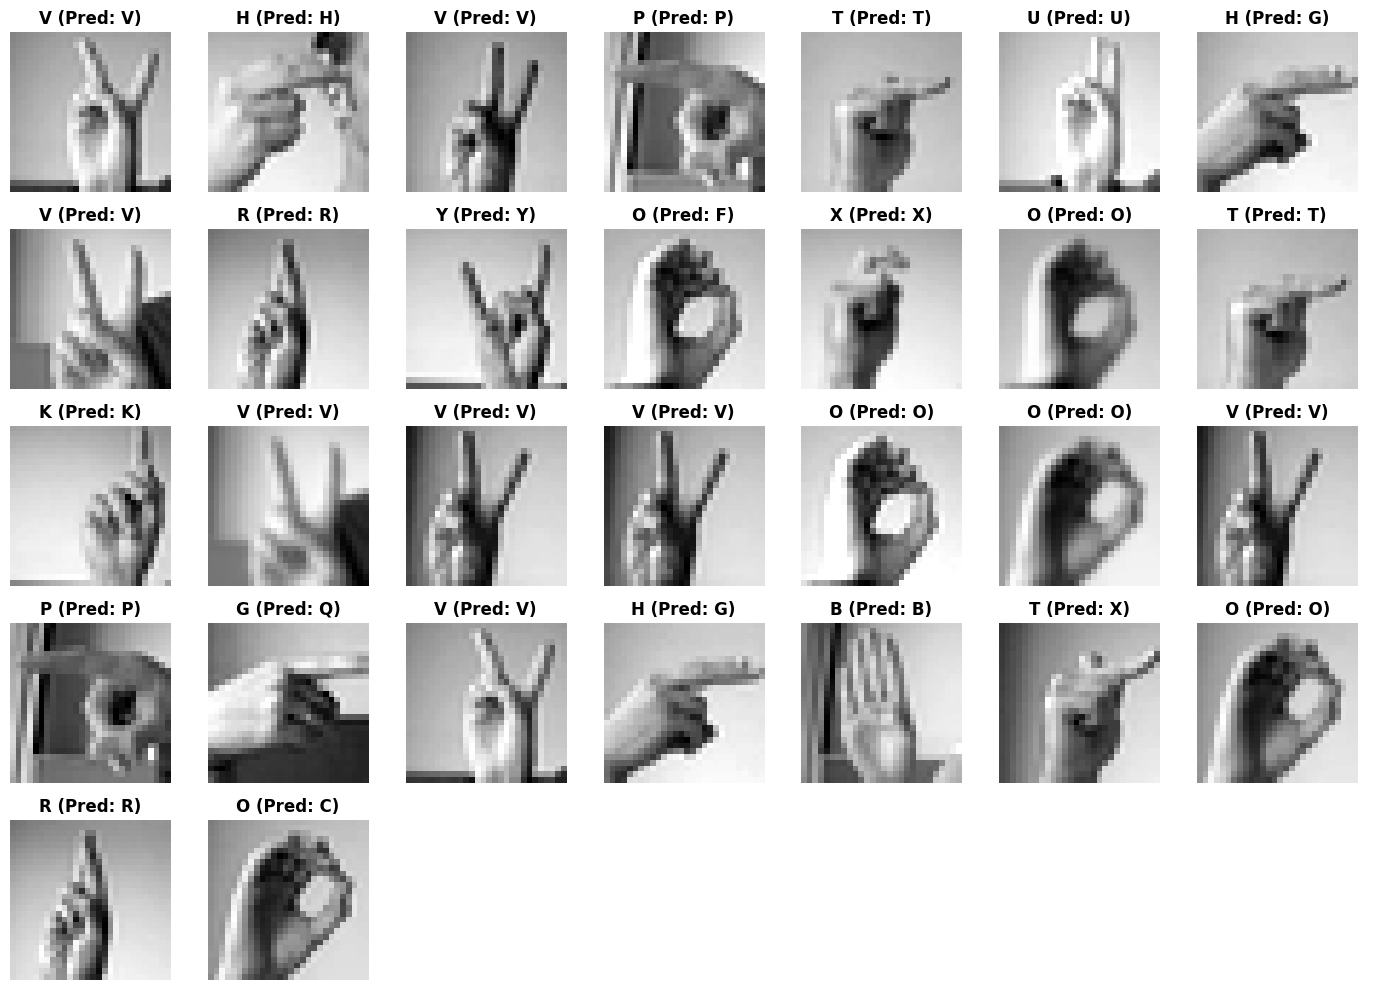

In [ ]:
# revisar las predicciones fallidas del modelo inicial

#k = 30 # ver 30 fallos
#criterio_fallos_inicial = df_preds['label'] != df_preds['pred']
#df_fallos_inicial = X_test[criterio_fallos_inicial][:k]
#y_fallos_inicial = y_test[criterio_fallos_inicial][:k]
#y_pred_fallos_inicial = y_test_pred[criterio_fallos_inicial][:k]
y_nueva_pred = y_test_pred[criterio_fallos_inicial][:k]

dibujar_letras_y_predicciones(df_fallos_inicial, y_fallos_inicial, y_nueva_pred)

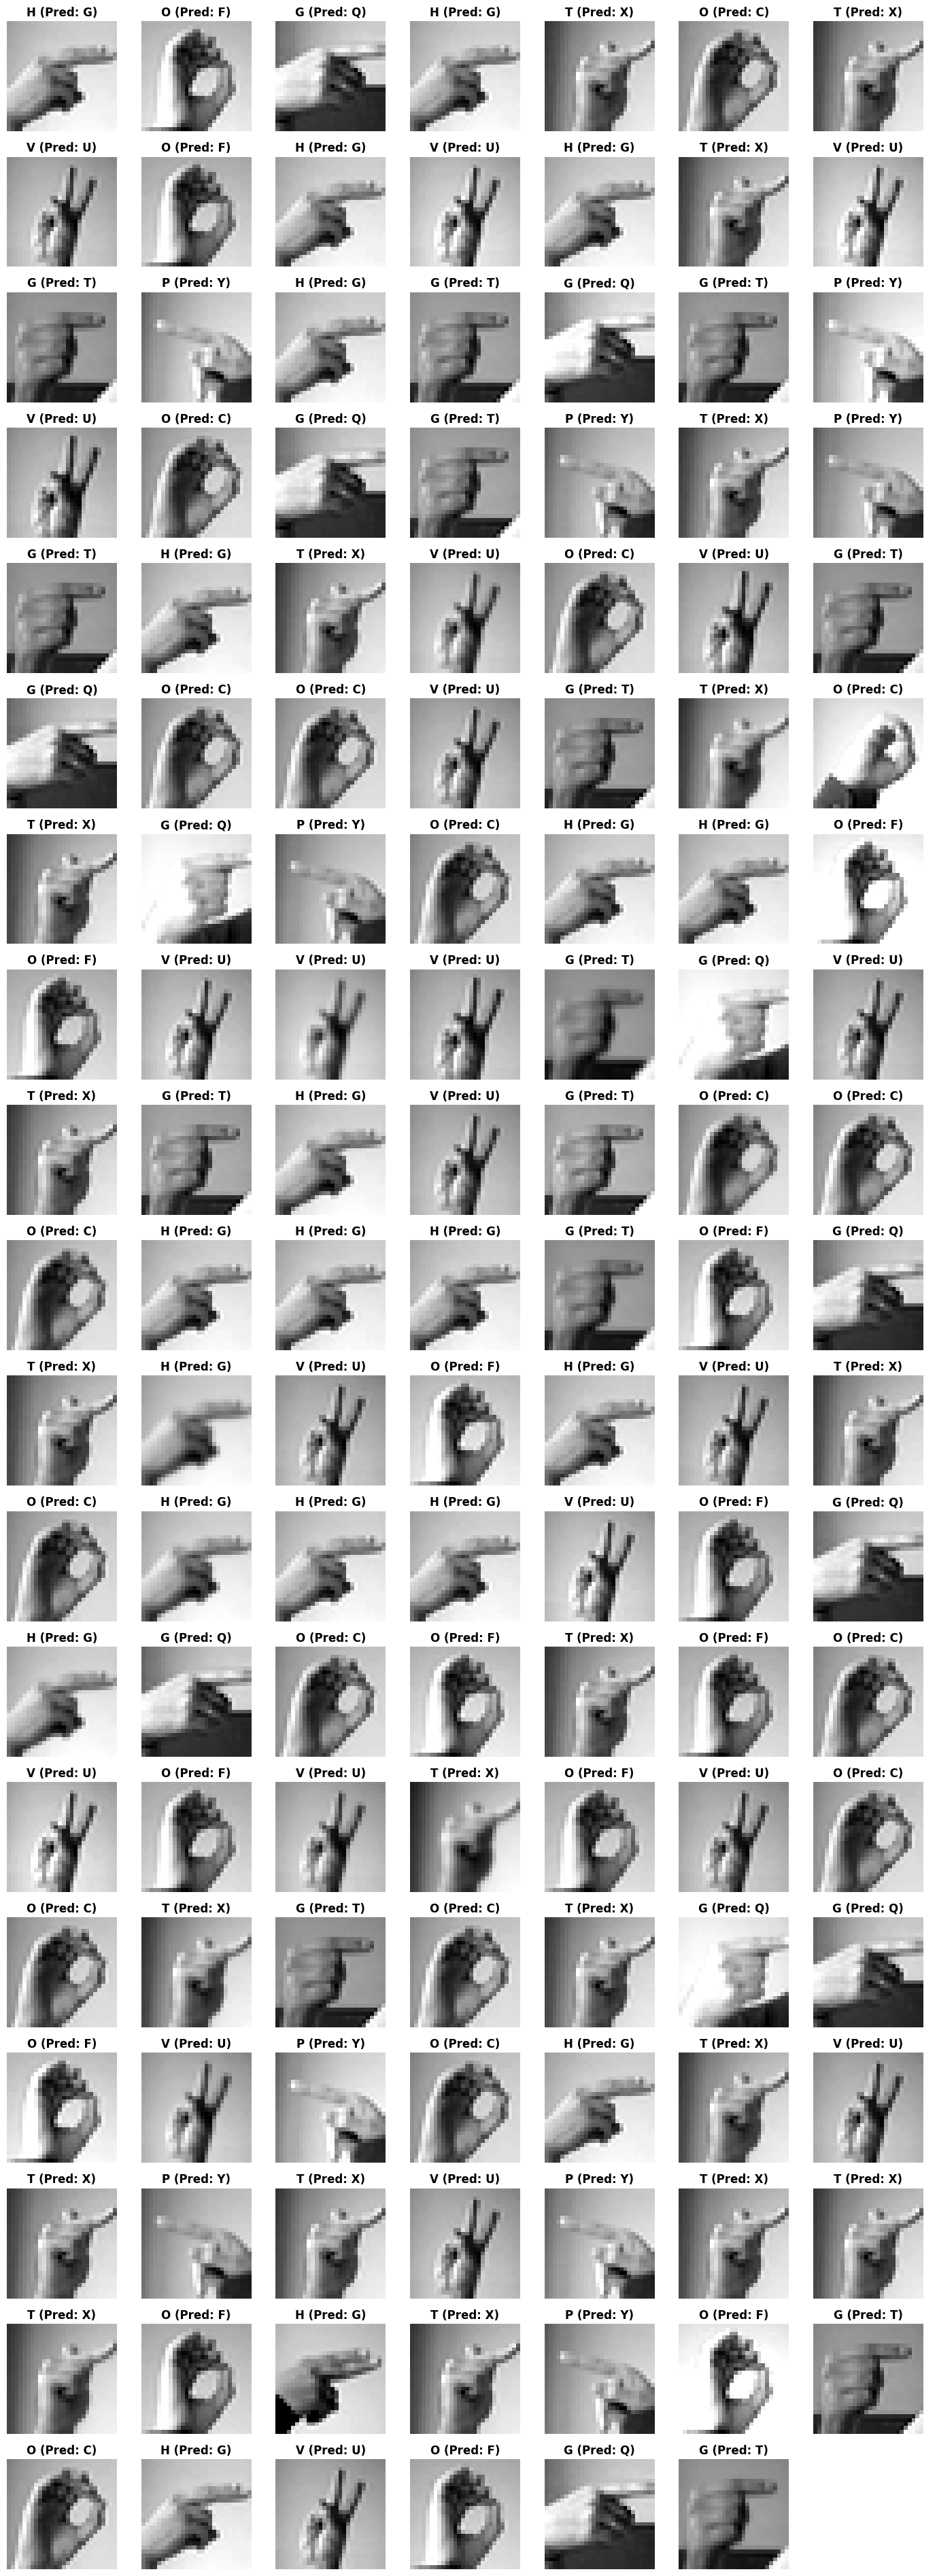

In [ ]:
# revisemos todas las predicciones fallidas para este nuevo modelo

df_preds = pd.DataFrame({'label': df_test.label, 'pred': y_test_pred})

criterio_fallos_aug = df_preds['label'] != df_preds['pred']
df_fallos_aug = X_test[criterio_fallos_aug]
y_fallos_aug = y_test[criterio_fallos_aug]
y_pred_fallos_aug = y_test_pred[criterio_fallos_aug]

dibujar_letras_y_predicciones(df_fallos_aug, y_fallos_aug, y_pred_fallos_aug)

In [ ]:
df_fallos = df_preds.loc[df_preds.label!=df_preds.pred, :].copy()
df_fallos.label = df_fallos.label.map(num_a_letras)
df_fallos.pred = df_fallos.pred.map(num_a_letras)
df_fallos = df_fallos.groupby('label').agg({'pred': 'value_counts'})
df_fallos.columns = ['num_fallos']
df_fallos

num_fallos
label pred            
G     T             14
      Q             12
H     G             21
O     C             18
      F             15
P     Y              9
T     X             21
V     U             22

In [ ]:
pd.set_option('display.max_columns', None)

df_prob = pd.DataFrame(y_test_pred_proba, columns=[num_a_letras[i] for i in sorted(y_test.unique())])
df_prob = pd.concat([df_preds, df_prob], axis=1)
df_prob.label = df_prob.label.map(num_a_letras)
df_prob.pred = df_prob.pred.map(num_a_letras)
df_prob[(df_prob.label=='V') & (df_prob.pred=='U')]

,label,pred,A,B,C,D,E,F,G,H,I,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y
411,V,U,1.238612e-08,1.566064e-08,5.795455e-10,1.825169e-07,1.555287e-09,7.062562e-08,4.257574e-10,4.102954e-09,3.404230e-07,2.865734e-08,3.707728e-09,3.467853e-06,1.969512e-07,2.808126e-11,8.184355e-09,2.500281e-07,3.031830e-07,1.195909e-06,1.648516e-10,0.984901,0.015093,1.645232e-07,2.877580e-09,1.617607e-08
489,V,U,1.553510e-08,1.210092e-08,8.282459e-10,2.205684e-07,2.624505e-09,1.275828e-07,5.750095e-10,5.579567e-09,3.730497e-07,3.443189e-08,4.799661e-09,6.581656e-06,3.318366e-07,3.870442e-11,6.970357e-09,3.543979e-07,2.876389e-07,2.132887e-06,2.348143e-10,0.981058,0.018931,1.449186e-07,2.473223e-09,2.198452e-08
638,V,U,9.231100e-09,3.948437e-09,3.870094e-10,2.369039e-07,1.900557e-09,5.788181e-08,3.304154e-10,2.639529e-09,1.149360e-07,2.373734e-08,2.611271e-09,4.935926e-06,3.047426e-07,1.876684e-11,3.642935e-09,2.005611e-07,1.429090e-07,2.046590e-06,1.034581e-10,0.992912,0.007080,4.346051e-08,1.309186e-09,8.541363e-09
949,V,U,6.708730e-09,1.465896e-10,3.930192e-09,8.023329e-04,3.467873e-09,7.214687e-07,1.122228e-09,8.028015e-08,5.688938e-08,7.550661e-08,5.719367e-09,9.550436e-07,1.268758e-07,9.309206e-10,5.303541e-09,1.701617e-07,1.016140e-07,9.284294e-06,1.927781e-09,0.697898,0.301287,8.239009e-08,2.939147e-08,1.421088e-09
1354,V,U,5.843967e-09,5.680507e-08,2.863678e-10,7.020928e-08,1.025695e-09,2.948076e-08,3.583549e-10,6.624634e-09,1.953774e-07,1.974204e-08,1.600922e-09,1.325303e-06,4.452749e-08,2.915638e-11,7.113705e-09,1.756815e-07,2.550711e-07,3.729862e-07,2.264025e-10,0.982286,0.017711,5.860918e-07,2.711267e-09,1.293660e-08
1597,V,U,6.300322e-09,1.818965e-10,4.689483e-09,7.707268e-04,4.292097e-09,9.730559e-07,1.289604e-09,9.481191e-08,9.575859e-08,9.051011e-08,7.395315e-09,9.762524e-07,1.558301e-07,1.135552e-09,6.015973e-09,2.258524e-07,9.979288e-08,1.040181e-05,2.436675e-09,0.626390,0.372826,1.091902e-07,3.203158e-08,1.731550e-09
2116,V,U,3.178836e-08,3.956835e-08,8.622294e-10,5.734107e-07,2.076765e-09,8.436201e-08,9.494117e-10,4.960652e-09,6.056163e-07,3.769242e-08,1.002490e-08,3.751959e-06,2.292952e-07,3.175976e-11,1.889565e-08,1.997486e-07,4.224715e-07,1.348007e-06,3.643035e-10,0.984514,0.015479,2.667083e-07,9.782875e-09,1.571395e-08
2860,V,U,1.687161e-08,2.346160e-08,8.265615e-10,1.954656e-07,2.437494e-09,1.223329e-07,6.355382e-10,6.507725e-09,6.401452e-07,4.750216e-08,4.549871e-09,5.035660e-06,2.751246e-07,4.178785e-11,1.041267e-08,4.215808e-07,3.482508e-07,1.573512e-06,2.798856e-10,0.976566,0.023425,2.927156e-07,3.965222e-09,2.802737e-08
2917,V,U,2.797995e-09,2.885558e-07,7.417159e-10,4.604229e-08,2.843331e-09,1.526212e-07,1.206979e-09,2.522467e-08,3.256201e-07,8.638496e-08,2.567619e-09,4.146963e-06,8.234991e-08,2.192755e-10,1.505567e-08,4.136475e-07,9.844013e-07,3.850514e-07,1.422753e-09,0.856094,0.143892,6.485949e-06,3.975251e-09,3.257796e-08
2989,V,U,6.617583e-09,1.950248e-10,4.160384e-09,6.390598e-04,3.722642e-09,8.515390e-07,1.096196e-09,8.229627e-08,9.576041e-08,6.735915e-08,7.005363e-09,9.896337e-07,1.226302e-07,9.900852e-10,5.892641e-09,1.949598e-07,9.959634e-08,1.028749e-05,2.185138e-09,0.672807,0.326541,1.070775e-07,2.882706e-08,1.878622e-09


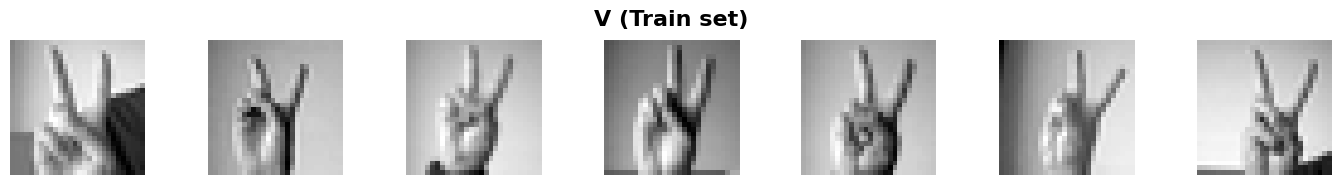

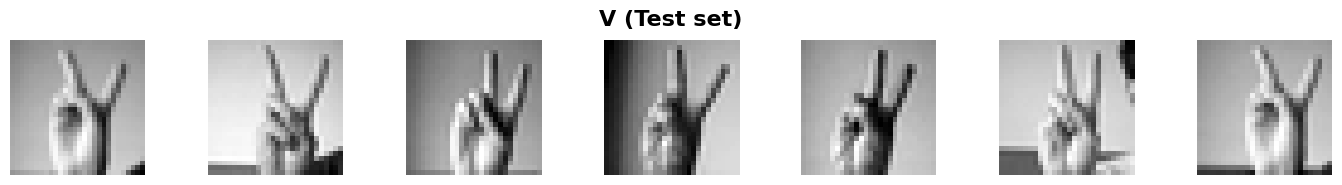

In [ ]:
dibujar_letra(df, 'V')
dibujar_letra(df_test, 'V')

###**Comparación de modelos**

In [ ]:
# comparación de accuracies
print(f'Accuracy en el test_set para el modelo inicial: {acc_test_original:.2%}')
print(f'Accuracy en el test set para el modelo aumentado: {acc_test_aug:.2%}')

Accuracy en el test_set para el modelo inicial: 89.29%
Accuracy en el test set para el modelo aumentado: 98.16%


###**Análisis**

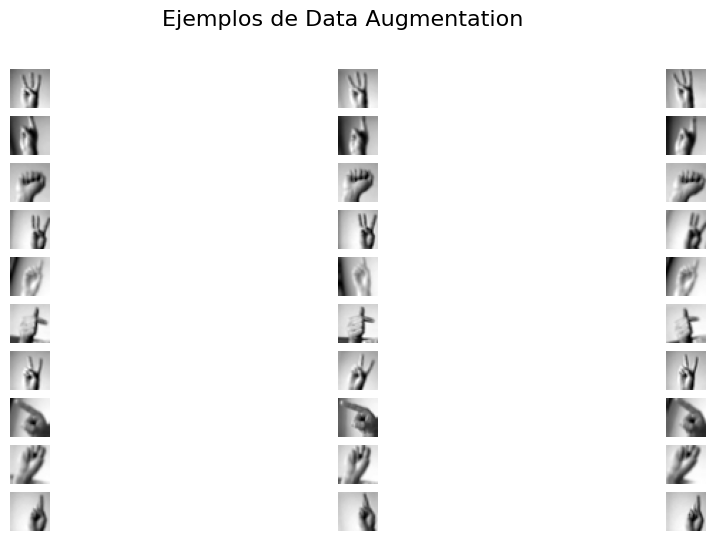

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Supongamos que tienes un lote de imágenes en X_train
# (si usas imágenes en escala de grises, asegúrate de expandir dimensiones con np.expand_dims)
sample_images = X_train[:10].to_numpy() # Convert DataFrame to NumPy array

# Aplica varias veces data_augmentation a cada imagen
plt.figure(figsize=(12, 6))
for i in range(10):  # 10 imágenes originales
    for j in range(3):  # 3 versiones aumentadas de cada una
        ax = plt.subplot(10, 3, i*3 + j + 1)
        # Reshape the image to (28, 28, 1) before applying data augmentation
        reshaped_img = sample_images[i].reshape(28, 28, 1)
        augmented_img = data_augmentation(tf.expand_dims(reshaped_img, 0))  # aplicar en batch
        # Scale pixel values back to 0-255 and convert to uint8
        plt.imshow(tf.cast(augmented_img[0] * 255, dtype=tf.uint8).numpy().squeeze(), cmap="gray")
        plt.axis("off")
plt.suptitle("Ejemplos de Data Augmentation", fontsize=16)
plt.show()